# SAM 3 fine-tuning for (blurry) alumina grains

Decoder-only fine-tune of **SAM 3's promptable mask decoder** (4.2M params; the 454M vision
encoder and the prompt encoder stay frozen). Because the encoder is frozen, every image's
embeddings are computed **once** and cached, so each training step only runs the tiny decoder —
this trains in minutes on Apple Silicon (MPS).

Recipe (as discussed):
- every annotated grain is a training sample: 1-2 random interior points (+ sometimes a
  background point) prompt the decoder, which is trained against that grain's mask
- loss = 20·Focal + Dice + IoU-head MSE (the SAM-paper mix)
- optional **blur/noise augmentation** through `synthetic_degradation.py` (each variant gets its
  own cached embedding), plus random flips/rotations
- validation = **whole held-out images**, scored by per-grain IoU from a deterministic
  most-interior-point prompt; early stopping keeps the best decoder

**Experiment arms** (change `TRAIN_FOLDERS` / `N_DEGRADED_VARIANTS` and re-run):

| arm | setup |
|---|---|
| B: blurry-only | `TRAIN_FOLDERS` = Wilson images only, `N_DEGRADED_VARIANTS = 0` |
| C: degraded clean | clean folders only, `N_DEGRADED_VARIANTS > 0` |
| D: combined | clean + blurry folders, `N_DEGRADED_VARIANTS > 0` |
| E: ablation | like C but widen/randomize `AUG_THETA` instead of BO-fitted values |

Run with the **`segmenteverygrain_new_SAM`** kernel. Masks are read with the project convention
(class 1 = grain interior); the SAM3 pseudo-label masks (1/2/3 with 3 = ignore) work unchanged
since only class 1 is sampled.

In [1]:
# ---------------- Config ----------------
TRAIN_FOLDERS = ["alumina_training_data"]        # add "testcleanimages_sam3_auto" for pseudo-labels
VAL_STEMS = [                                    # whole images held out (never trained on)
    "cropped_Wilson180_0.25__surface1_12",       # real blurry
    "prac7_etched_099",                          # clean
]

N_DEGRADED_VARIANTS = 3      # synthetic blur/noise variants per training image (0 = off)
GEOMETRIC_AUG = True         # random flip/rot90 baked into each variant
# Degradation parameter ranges [low, high] for theta = [sigma_psf, contrast, a, b, sigma_r, l, k].
# Replace with a tight range around your BO-fitted theta once you have it (synthetic_degradation.py).
AUG_THETA = {
    "sigma_psf": (0.5, 4.0), "contrast": (0.5, 1.0),
    "a": (0.001, 0.006), "b": (0.0008, 0.004), "sigma_r": (0.0003, 0.002),
    "l": (0.4, 1.5), "k": (0.03, 0.15),
}

STEPS = 600                  # decoder update steps
GRAINS_PER_STEP = 8
LR = 1e-4
VAL_EVERY = 50
PATIENCE = 4                 # stop after this many val checks without improvement
MIN_GRAIN_SIZE = 25          # px; smaller GT components are ignored
SEED = 42

OUT_DECODER = "models/sam3_decoder_alumina_ft.pt" 

In [2]:
import os
os.environ["HF_HUB_OFFLINE"] = "1"          # comment out to (re)download weights
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import copy, glob, time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
from scipy import ndimage
from skimage.measure import label as connected_components
from transformers import Sam3TrackerModel, Sam3TrackerProcessor

from synthetic_degradation import params_from_theta, synthetic_degradation_model_input

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
rng = np.random.default_rng(SEED)

processor = Sam3TrackerProcessor.from_pretrained("facebook/sam3")
model = Sam3TrackerModel.from_pretrained("facebook/sam3").to(device)
for p in model.parameters():
    p.requires_grad_(False)
for p in model.mask_decoder.parameters():
    p.requires_grad_(True)
model.eval()                                 # BN/dropout off; decoder still gets gradients
base_decoder_state = copy.deepcopy(model.mask_decoder.state_dict())   # for before/after comparison

n_train = sum(p.numel() for p in model.mask_decoder.parameters())
print(f"{device}: training {n_train/1e6:.1f}M of {sum(p.numel() for p in model.parameters())/1e6:.0f}M params")

/Users/Alexander/miniforge3/envs/segmenteverygrain_new_SAM/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[transformers] You are using a model of type `sam3_video` to instantiate a model of type `sam3_tracker`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/685 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 685/685 [00:00<00:00, 10823.87it/s]

mps: training 4.2M of 458M params


## 1. Data

Image/mask pairs are matched by the `{stem}_image.*` / `{stem}_mask.*` convention. Ground-truth
grains = connected components of mask class 1 (≥ `MIN_GRAIN_SIZE` px). Sparse annotations (like
the Wilson masks) are fine: only annotated grains are ever sampled.

In [3]:
def find_pairs(folder):
    pairs = []
    for img_fn in sorted(glob.glob(os.path.join(folder, "*_image.*"))):
        stem = os.path.basename(img_fn).rsplit("_image", 1)[0]
        for ext in (".tif", ".png", ".tiff", ".jpg"):
            mask_fn = os.path.join(folder, f"{stem}_mask{ext}")
            if os.path.exists(mask_fn):
                pairs.append((stem, img_fn, mask_fn))
                break
    return pairs


def instances_from_mask(mask_fn, min_size=MIN_GRAIN_SIZE):
    m = np.array(Image.open(mask_fn))
    m = m[..., 0] if m.ndim == 3 else m
    inst = connected_components(m == 1, connectivity=1)
    sizes = np.bincount(inst.ravel())
    for i in np.where(sizes < min_size)[0]:
        inst[inst == i] = 0
    return connected_components(inst > 0, connectivity=1)


train_pairs, val_pairs = [], []
for folder in TRAIN_FOLDERS:
    for stem, img_fn, mask_fn in find_pairs(folder):
        (val_pairs if stem in VAL_STEMS else train_pairs).append((stem, img_fn, mask_fn))

print(f"train images: {len(train_pairs)}, val images: {len(val_pairs)}")
for tag, pairs in [("train", train_pairs), ("val", val_pairs)]:
    for stem, _, mask_fn in pairs:
        print(f"  [{tag}] {stem}: {instances_from_mask(mask_fn).max()} grains")
assert train_pairs and val_pairs, 'check TRAIN_FOLDERS / VAL_STEMS'

train images: 6, val images: 2


  [train] cropped_Wilson180_0.25__surface1_08: 53 grains


  [train] cropped_Wilson180_0.25__surface1_09: 69 grains


  [train] cropped_Wilson180_0.25__surface1_10: 57 grains


  [train] cropped_Wilson180_0.25__surface1_11: 62 grains
  [train] prac7_etched_070: 260 grains
  [train] prac7_etched_090: 221 grains


  [val] cropped_Wilson180_0.25__surface1_12: 57 grains
  [val] prac7_etched_099: 252 grains


## 2. Augmentation

Each degraded variant is a *new image* (blur → contrast → noise from `synthetic_degradation.py`,
plus optional flip/rot90), so it gets its own cached embedding below. Labels transform with the
geometry and survive the degradation unchanged.

In [4]:
def sample_theta(rng):
    return params_from_theta([rng.uniform(*AUG_THETA[k]) for k in
                              ("sigma_psf", "contrast", "a", "b", "sigma_r", "l", "k")])


def degrade(image_rgb, rng):
    x = np.asarray(image_rgb, np.float32).mean(-1) / 255.0
    y = synthetic_degradation_model_input(x, sample_theta(rng), rng)
    return np.stack([np.clip(y, 0, 1) * 255] * 3, -1).astype(np.uint8)


def random_geometry(image, inst, rng):
    k = int(rng.integers(0, 4))
    image, inst = np.rot90(image, k, (0, 1)), np.rot90(inst, k, (0, 1))
    if rng.random() < 0.5:
        image, inst = np.flip(image, 1), np.flip(inst, 1)
    return np.ascontiguousarray(image), np.ascontiguousarray(inst)

## 3. Cache image embeddings

One frozen-encoder pass per image variant (a few seconds each on MPS), cached on CPU. After
this, training never touches the encoder.

In [5]:
def to_device(obj, dev):
    if torch.is_tensor(obj):
        return obj.to(dev)
    if isinstance(obj, (list, tuple)):
        return type(obj)(to_device(o, dev) for o in obj)
    if isinstance(obj, dict):
        return {k: to_device(v, dev) for k, v in obj.items()}
    return obj


@torch.no_grad()
def embed(image_rgb):
    inputs = processor(images=image_rgb, return_tensors="pt").to(device)
    return to_device(model.get_image_embeddings(inputs["pixel_values"]), "cpu")


train_records, val_records = [], []   # (embeddings_cpu, instance_map, original_size, tag)
t0 = time.time()
for stem, img_fn, mask_fn in train_pairs:
    image = np.array(Image.open(img_fn).convert("RGB"))
    inst = instances_from_mask(mask_fn)
    train_records.append((embed(image), inst, image.shape[:2], stem))
    for v in range(N_DEGRADED_VARIANTS):
        img_v, inst_v = (random_geometry(image, inst, rng) if GEOMETRIC_AUG else (image, inst))
        img_v = degrade(img_v, rng)
        train_records.append((embed(img_v), inst_v, img_v.shape[:2], f"{stem}~aug{v}"))
    print(f"  {stem}: 1 + {N_DEGRADED_VARIANTS} variants embedded", flush=True)

for stem, img_fn, mask_fn in val_pairs:
    image = np.array(Image.open(img_fn).convert("RGB"))
    val_records.append((embed(image), instances_from_mask(mask_fn), image.shape[:2], stem))

print(f"{len(train_records)} train / {len(val_records)} val embeddings in {time.time()-t0:.0f}s")

  cropped_Wilson180_0.25__surface1_08: 1 + 3 variants embedded


  cropped_Wilson180_0.25__surface1_09: 1 + 3 variants embedded


  cropped_Wilson180_0.25__surface1_10: 1 + 3 variants embedded


  cropped_Wilson180_0.25__surface1_11: 1 + 3 variants embedded


  prac7_etched_070: 1 + 3 variants embedded


  prac7_etched_090: 1 + 3 variants embedded


24 train / 2 val embeddings in 107s


## 4. Prompted decoder forward, loss, and per-grain evaluation

In [6]:
def forward_grains(emb_cpu, points_list, labels_list, original_size, grad=True):
    """points_list: list of B (N, 2) float arrays (x, y). Returns logits (B, 1, H, W), iou (B,)."""
    inputs = processor(
        original_sizes=[list(original_size)],
        input_points=[[p.tolist() for p in points_list]],
        input_labels=[[list(l) for l in labels_list]],
        return_tensors="pt",
    ).to(device)
    with (torch.enable_grad() if grad else torch.no_grad()):
        out = model(image_embeddings=to_device(emb_cpu, device),
                    input_points=inputs["input_points"],
                    input_labels=inputs["input_labels"],
                    multimask_output=False)
        logits = F.interpolate(out.pred_masks[0], size=original_size,
                               mode="bilinear", align_corners=False)
    return logits, out.iou_scores.reshape(-1)


def losses(logits, gt, iou_pred):
    p = torch.sigmoid(logits)
    inter = (p * gt).sum((-2, -1))
    dice = 1 - (2 * inter + 1) / ((p + gt).sum((-2, -1)) + 1)
    bce = F.binary_cross_entropy_with_logits(logits, gt, reduction="none")
    pt = torch.exp(-bce)
    focal = (0.25 * (1 - pt) ** 2 * bce).mean((-2, -1))
    with torch.no_grad():
        hard = (logits > 0).float()
        iou_true = ((hard * gt).sum((-2, -1)) + 1) / (((hard + gt) > 0).float().sum((-2, -1)) + 1)
    return 20 * focal.mean() + dice.mean() + F.mse_loss(iou_pred, iou_true.reshape(-1))


def sample_interior(m, n, rng):
    core = ndimage.binary_erosion(m, iterations=3)
    ys, xs = np.where(core if core.any() else m)
    i = rng.integers(0, len(ys), n)
    return np.column_stack([xs[i], ys[i]]).astype(float)


def sample_ring(m, n, rng):
    ring = ndimage.binary_dilation(m, iterations=10) & ~m
    ys, xs = np.where(ring if ring.any() else ~m)
    i = rng.integers(0, len(ys), n)
    return np.column_stack([xs[i], ys[i]]).astype(float)


@torch.no_grad()
def per_grain_iou(emb_cpu, inst, original_size, chunk=16, max_grains=None):
    """Deterministic eval: one most-interior point per grain -> IoU vs GT."""
    ids = np.arange(1, inst.max() + 1)[:max_grains]
    ious = []
    for i in range(0, len(ids), chunk):
        pts, gts = [], []
        for gid in ids[i:i + chunk]:
            g = inst == gid
            d = ndimage.distance_transform_edt(g)
            y, x = np.unravel_index(np.argmax(d), d.shape)
            pts.append(np.array([[x, y]], float))
            gts.append(g)
        logits, _ = forward_grains(emb_cpu, pts, [[1]] * len(pts), original_size, grad=False)
        pred = (logits[:, 0] > 0).cpu().numpy()
        ious += [(p & g).sum() / max((p | g).sum(), 1) for p, g in zip(pred, gts)]
    return float(np.mean(ious))


def val_score():
    return {tag: per_grain_iou(emb, inst, osize) for emb, inst, osize, tag in val_records}

## 5. Train

Each step: pick a random (possibly augmented) image, sample `GRAINS_PER_STEP` grains, prompt with
1-2 interior points (+ a background point half the time), update the decoder. Early stopping on
mean validation per-grain IoU.

In [7]:
baseline = val_score()
print("baseline per-grain IoU:", {k: round(v, 3) for k, v in baseline.items()})

opt = torch.optim.AdamW(model.mask_decoder.parameters(), lr=LR, weight_decay=0.01)
history = {"step": [], "loss": [], "val_step": [], "val_iou": []}
best_iou, best_state, checks_since_best = float(np.mean(list(baseline.values()))), None, 0

t0 = time.time()
for step in range(1, STEPS + 1):
    emb, inst, osize, _ = train_records[rng.integers(0, len(train_records))]
    n = inst.max()
    ids = rng.choice(np.arange(1, n + 1), size=min(GRAINS_PER_STEP, n), replace=False)
    n_pos = int(rng.integers(1, 3))
    use_neg = rng.random() < 0.5
    pts, lbls, gts = [], [], []
    for gid in ids:
        g = inst == gid
        p, l = sample_interior(g, n_pos, rng), [1] * n_pos
        if use_neg:
            p = np.vstack([p, sample_ring(g, 1, rng)])
            l.append(0)
        pts.append(p); lbls.append(l); gts.append(g)

    logits, iou_pred = forward_grains(emb, pts, lbls, osize, grad=True)
    gt = torch.as_tensor(np.stack(gts), dtype=torch.float, device=device)[:, None]
    loss = losses(logits, gt, iou_pred)
    opt.zero_grad(); loss.backward(); opt.step()
    history["step"].append(step); history["loss"].append(loss.item())

    if step % VAL_EVERY == 0:
        scores = val_score()
        mean_iou = float(np.mean(list(scores.values())))
        history["val_step"].append(step); history["val_iou"].append(mean_iou)
        marker = ""
        if mean_iou > best_iou:
            best_iou, checks_since_best = mean_iou, 0
            best_state = copy.deepcopy(model.mask_decoder.state_dict())
            marker = "  <-- best"
        else:
            checks_since_best += 1
        print(f"step {step:4d}: loss {np.mean(history['loss'][-VAL_EVERY:]):.3f} | "
              f"val IoU {mean_iou:.3f} { {k: round(v, 3) for k, v in scores.items()} }{marker}",
              flush=True)
        if checks_since_best >= PATIENCE:
            print("early stop")
            break

print(f"done in {(time.time()-t0)/60:.1f} min; best val IoU {best_iou:.3f} "
      f"(baseline {np.mean(list(baseline.values())):.3f})")

baseline per-grain IoU: {'cropped_Wilson180_0.25__surface1_12': 0.686, 'prac7_etched_099': 0.629}


step   50: loss 0.423 | val IoU 0.677 {'cropped_Wilson180_0.25__surface1_12': 0.708, 'prac7_etched_099': 0.646}  <-- best


step  100: loss 0.356 | val IoU 0.688 {'cropped_Wilson180_0.25__surface1_12': 0.727, 'prac7_etched_099': 0.649}  <-- best


step  150: loss 0.364 | val IoU 0.690 {'cropped_Wilson180_0.25__surface1_12': 0.739, 'prac7_etched_099': 0.641}  <-- best


step  200: loss 0.347 | val IoU 0.700 {'cropped_Wilson180_0.25__surface1_12': 0.741, 'prac7_etched_099': 0.659}  <-- best


...

step  300: loss 0.334 | val IoU 0.700 {'cropped_Wilson180_0.25__surface1_12': 0.742, 'prac7_etched_099': 0.658}


step  350: loss 0.343 | val IoU 0.696 {'cropped_Wilson180_0.25__surface1_12': 0.743, 'prac7_etched_099': 0.648}


step  400: loss 0.361 | val IoU 0.699 {'cropped_Wilson180_0.25__surface1_12': 0.741, 'prac7_etched_099': 0.657}


step  450: loss 0.376 | val IoU 0.699 {'cropped_Wilson180_0.25__surface1_12': 0.742, 'prac7_etched_099': 0.656}


early stop
done in 4.2 min; best val IoU 0.701 (baseline 0.657)


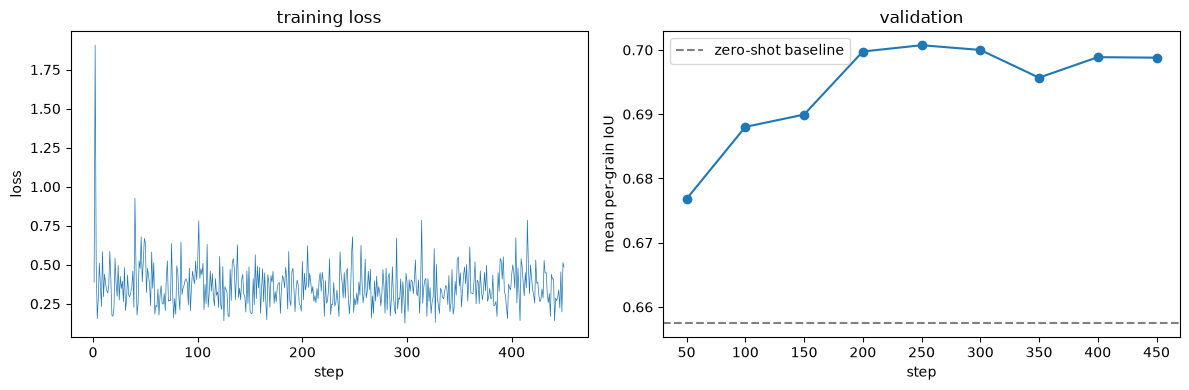

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["step"], history["loss"], lw=0.5)
axes[0].set(xlabel="step", ylabel="loss", title="training loss")
axes[1].plot(history["val_step"], history["val_iou"], "o-")
axes[1].axhline(np.mean(list(baseline.values())), ls="--", c="gray", label="zero-shot baseline")
axes[1].set(xlabel="step", ylabel="mean per-grain IoU", title="validation")
axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Save best decoder + before/after comparison

In [9]:
if best_state is not None:
    model.mask_decoder.load_state_dict(best_state)
os.makedirs(os.path.dirname(OUT_DECODER), exist_ok=True)
torch.save(model.mask_decoder.state_dict(), OUT_DECODER)
print(f"saved fine-tuned decoder -> {OUT_DECODER}")

final = val_score()
print(f"{'image':<45} {'zero-shot':>9} {'fine-tuned':>10}")
for k in final:
    print(f"{k:<45} {baseline[k]:>9.3f} {final[k]:>10.3f}")

saved fine-tuned decoder -> models/sam3_decoder_alumina_ft.pt


image                                         zero-shot fine-tuned
cropped_Wilson180_0.25__surface1_12               0.686      0.746
prac7_etched_099                                  0.629      0.655


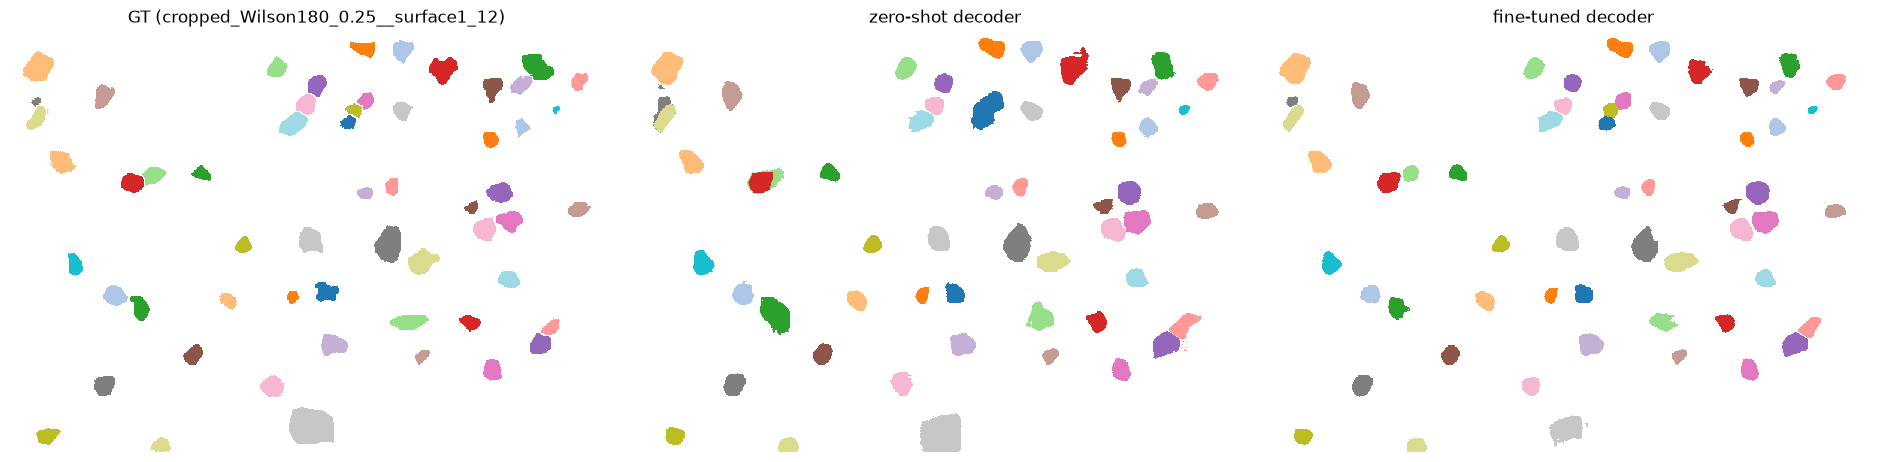

In [10]:
# Visual before/after on the first (blurry) validation image
emb, inst, osize, tag = val_records[0]
ids = np.arange(1, inst.max() + 1)

def render(state):
    model.mask_decoder.load_state_dict(state)
    out = np.zeros(osize, np.int32)
    for i in range(0, len(ids), 16):
        pts = []
        for gid in ids[i:i + 16]:
            d = ndimage.distance_transform_edt(inst == gid)
            y, x = np.unravel_index(np.argmax(d), d.shape)
            pts.append(np.array([[x, y]], float))
        logits, _ = forward_grains(emb, pts, [[1]] * len(pts), osize, grad=False)
        for j, gid in enumerate(ids[i:i + 16]):
            out[(logits[j, 0] > 0).cpu().numpy()] = gid
    return out

pred_base = render(base_decoder_state)
pred_ft = render(torch.load(OUT_DECODER, map_location=device))

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, (m, title) in zip(axes, [(inst, f"GT ({tag})"), (pred_base, "zero-shot decoder"),
                                 (pred_ft, "fine-tuned decoder")]):
    ax.imshow(np.where(m > 0, m % 20, np.nan), cmap="tab20", interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 7. Using the fine-tuned decoder

Drop it into the interactive annotator / `Sam3Predictor` (they share this exact decoder):

```python
from sam3_predictor import Sam3Predictor
import torch

predictor = Sam3Predictor()
predictor.model.mask_decoder.load_state_dict(
    torch.load("models/sam3_decoder_alumina_ft.pt", map_location=predictor.device))
```

For the automatic `mask-generation` pipeline, the checkpoint's full model wraps the same
tracker; after building the pipeline try
`generator.model.mask_decoder.load_state_dict(torch.load(...))` — if the attribute path differs
in your transformers version, inspect `generator.model` for the decoder submodule.

Caveats worth remembering:
- This tunes the **promptable** path. It directly improves point/box-prompted segmentation (the
  annotator, prompted pipelines); automatic mask generation also runs through the decoder but
  its proposal/filtering stages are unchanged.
- With this little data, watch the val curve for overfitting — the whole-image holdout is your
  only protection. For the arms-B-through-E comparison, keep `VAL_STEMS` identical across runs.